# Pandas, NumPy, Matplotlib, and Cleaning Basin Data

In this notebook you will work with real daily basin data from **Ala-Archa** and **Alamedin**.

Our long-term goal is to calibrate a hydrological model that predicts discharge from meteorological inputs. For that we need a clean daily dataset where precipitation, temperature, and measured discharge all line up on the same dates.

This notebook is about building that dataset carefully.

By the end of the notebook you will:

- use `numpy` to represent missing values
- use `pandas` to read CSV files into DataFrames
- merge precipitation, temperature, and discharge into one coherent daily table
- use plots to spot suspicious values
- remove a few obvious outliers
- measure streamflow gap lengths
- interpolate only short internal gaps of up to 3 days
- save cleaned datasets for later model calibration


## How To Work Through This Notebook

Ala-Archa is the guided example. Alamedin is the transfer exercise at the end.

The workflow is intentionally iterative:

1. build a first version of the dataset
2. inspect it
3. notice a problem
4. fix that problem
5. inspect again

That is a normal part of working with real environmental data.


## 1. Imports, Paths, and Missing Data

We will use three Python libraries in this notebook:

- `numpy` for numerical values such as arrays and missing numeric values
- `pandas` for table-like data structures called **DataFrames**
- `matplotlib` for plotting


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
PROJECT_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "data" / "02_data").exists()
)
DATA_ROOT = PROJECT_ROOT / "data" / "02_data"

ala_archa_folder = "15194_AlaArcha_River_KGZ"
ala_archa_gauge_code = "15194"
ala_archa_area_km2 = 271.34

alamedin_folder = "15189_Alamedin_River_KGZ"
alamedin_gauge_code = "15189"
alamedin_area_km2 = 418.93

print(DATA_ROOT)
print(DATA_ROOT.exists())


Real measurement records are rarely complete. A station may stop recording for a few days, a sensor can fail, or a value may be removed later because it is clearly wrong.

In Python, missing numeric data is commonly represented with **NaN**, which stands for *not a number*.

With `numpy`, that value is written as `np.nan`. `pandas` understands it as a missing entry inside a DataFrame.


In [3]:
missing_streamflow_value = np.nan

print(missing_streamflow_value)
print(pd.isna(missing_streamflow_value))


nan
True


The `True` from `pd.isna(...)` tells us that Python recognizes this value as missing.

That idea will come back several times in this notebook, because streamflow gaps will appear in our tables exactly in this form.


### Exercise 1

The goal of this exercise is to make the missing-value idea concrete before we move to real data.

Create a variable called `student_missing_value` and store `np.nan` in it.
Then create `student_value_is_missing` with `pd.isna(...)`.


In [4]:
student_missing_value = np.nan
student_value_is_missing = pd.isna(student_missing_value)

print(student_value_is_missing)


True


In [5]:
assert pd.isna(student_missing_value), "`student_missing_value` should contain `np.nan`."
assert student_value_is_missing is True, "`student_value_is_missing` should be `True`."

## 2. Read the Forcing Data with `pandas`

To predict discharge later, we will need meteorological inputs.

For this course, the precipitation and temperature data were already prepared from **ERA5-Land** reanalysis and saved as CSV files. They come in **two separate files**:

- one for precipitation
- one for temperature

We want to combine them for convenience so that each day has both forcing variables in one table.

This is a good moment to introduce **pandas**.

A `pandas` **DataFrame** is a table with rows and columns. If you know Excel, that is a useful first mental picture: each row is one record, each column is one variable, and the column names describe what is stored there.

`pd.read_csv(...)` reads a CSV file into a DataFrame. `.head()` shows the first few rows so we can inspect what was loaded.


In [6]:
ala_archa_precipitation_path = DATA_ROOT / ala_archa_folder / "02_forcing" / "era5_precipitation_daily.csv"
ala_archa_temperature_path = DATA_ROOT / ala_archa_folder / "02_forcing" / "era5_temperature_daily.csv"

ala_archa_precipitation_df = pd.read_csv(ala_archa_precipitation_path, parse_dates=["date"])
ala_archa_temperature_df = pd.read_csv(ala_archa_temperature_path, parse_dates=["date"])

print(ala_archa_precipitation_df.head())
print()
print(ala_archa_temperature_df.head())


        date  precipitation_mm
0 1981-01-01            0.5252
1 1981-01-02            0.2056
2 1981-01-03            0.1817
3 1981-01-04            0.6073
4 1981-01-05            0.8798

        date  temperature_degC
0 1981-01-01           -9.0248
1 1981-01-02           -9.2665
2 1981-01-03           -9.5467
3 1981-01-04          -10.7114
4 1981-01-05          -12.1689


Each table is daily and already has a `date` column.

Using `parse_dates=["date"]` tells `pandas` to store the date column as an actual date type rather than plain text. That will be useful later when we filter by time periods.


### Exercise 2

The goal here is to practice reading a CSV into a DataFrame and inspecting it.

Read the **Alamedin** temperature file into `alamedin_temperature_df` and print its first five rows.


In [7]:
alamedin_temperature_path = DATA_ROOT / alamedin_folder / "02_forcing" / "era5_temperature_daily.csv"
alamedin_temperature_df = pd.read_csv(alamedin_temperature_path, parse_dates=["date"])

print(alamedin_temperature_df.head())


        date  temperature_degC
0 1981-01-01           -8.3541
1 1981-01-02           -8.6758
2 1981-01-03           -8.9181
3 1981-01-04          -10.1155
4 1981-01-05          -11.4220


Now we have two Ala-Archa DataFrames, both indexed by date. In `pandas`, joining two tables on a shared column is called a **merge**.

Here we merge on `date` so that each daily row contains both precipitation and temperature.


In [8]:
ala_archa_forcing_df = ala_archa_precipitation_df.merge(
    ala_archa_temperature_df,
    on="date",
    how="inner",
).sort_values("date").reset_index(drop=True)

print(ala_archa_forcing_df.head())

        date  precipitation_mm  temperature_degC
0 1981-01-01            0.5252           -9.0248
1 1981-01-02            0.2056           -9.2665
2 1981-01-03            0.1817           -9.5467
3 1981-01-04            0.6073          -10.7114
4 1981-01-05            0.8798          -12.1689


After the merge, the forcing data is more convenient to work with because the two meteorological variables now live in one common DataFrame.


### Exercise 3

The goal of this exercise is to inspect the merged DataFrame and confirm that the merge did what we expected.

Store these two values:

- `ala_archa_forcing_columns` as the column names of `ala_archa_forcing_df`
- `ala_archa_forcing_n_rows` as the number of rows in `ala_archa_forcing_df`


In [9]:
ala_archa_forcing_columns = ala_archa_forcing_df.columns.tolist()
ala_archa_forcing_n_rows = len(ala_archa_forcing_df)

print(ala_archa_forcing_columns)
print(ala_archa_forcing_n_rows)


['date', 'precipitation_mm', 'temperature_degC']
16071


In [10]:
assert ala_archa_forcing_columns == ["date", "precipitation_mm", "temperature_degC"], (
    "The forcing table should contain `date`, `precipitation_mm`, and `temperature_degC`."
)
assert ala_archa_forcing_n_rows == 16071, "Ala-Archa forcing should have 16071 daily rows."


## 3. Add Measured Discharge to Build One Common Daily Dataset

We now already have precipitation and temperature in one DataFrame.

The next step is to add the **measured discharge** from the gauge so that all three variables are aligned in one coherent daily table. That is the dataset we will later use as the starting point for model calibration.

The same `pandas` ideas still apply:

- `pd.read_csv(...)` to read the file
- date parsing to turn timestamps into daily dates
- selecting only the columns we need
- merging on `date`

The raw gauge file stores discharge in `m3/s`. For hydrological modelling it is often more convenient to express discharge as a depth over the catchment in `mm/day`:

`q_mm = q_m3s * 86.4 / area_km2`

That makes discharge directly comparable to precipitation and later model outputs.


In [11]:
ala_archa_streamflow_path = (
    DATA_ROOT / ala_archa_folder / "01_gauge_data" / f"q{ala_archa_gauge_code}_not_to_be_shared.csv"
)

ala_archa_streamflow_df = pd.read_csv(ala_archa_streamflow_path)

print(ala_archa_streamflow_df.head())

      q_m3s      local_date_time        utc_date_time
0  4.586328  2015-05-25 14:00:00  2015-05-25 08:00:00
1  4.451707  2015-05-26 14:00:00  2015-05-26 08:00:00
2  4.059874  2015-05-28 14:00:00  2015-05-28 08:00:00
3  4.188480  2015-05-29 14:00:00  2015-05-29 08:00:00
4  5.002225  2015-05-30 14:00:00  2015-05-30 08:00:00


The measured streamflow data has a `local_date_time` column. Let's rename it to `date`, following what we have for `ala_archa_forcing_df`

In [12]:
# Convert timestamps to daily standard dates and keep only needed columns
ala_archa_streamflow_df["date"] = pd.to_datetime(ala_archa_streamflow_df["local_date_time"]).dt.normalize()
ala_archa_streamflow_df = ala_archa_streamflow_df[["date", "q_m3s"]].copy()

# Determine the time period where we have streamflow data. Here we are trying to find the date of the first and last streamflow measurement, which we will use to filter the meteorological forcing data to the same period. There might be missing streamflow values in between, but we want to keep the full period of available streamflow data for the gap-filling exercise later on.
ala_archa_start_date = ala_archa_streamflow_df["date"].min()
ala_archa_end_date = ala_archa_streamflow_df["date"].max()

# Filter meteorological forcing to the streamflow period and merge them together
ala_archa_clean_df = (
    ala_archa_forcing_df[
        ala_archa_forcing_df["date"].between(ala_archa_start_date, ala_archa_end_date)
    ]  # this looks complicated but it is just filtering the forcing data to the same period as the streamflow data
    .merge(ala_archa_streamflow_df, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

# Convert discharge from m3/s to mm/day to match precipitation units
ala_archa_clean_df["q_mm"] = ala_archa_clean_df["q_m3s"] * 86.4 / ala_archa_area_km2

# Select and reorder the final columns for the daily dataset
ala_archa_clean_df = ala_archa_clean_df[["date", "precipitation_mm", "temperature_degC", "q_m3s", "q_mm"]].copy()

print(ala_archa_clean_df.head())

        date  precipitation_mm  temperature_degC     q_m3s      q_mm
0 2015-05-25            2.0104            0.2445  4.586328  1.460377
1 2015-05-26            0.8580            1.4076  4.451707  1.417511
2 2015-05-27            0.5951            2.9302       NaN       NaN
3 2015-05-28            1.4289            4.2443  4.059874  1.292744
4 2015-05-29            0.8399            5.7689  4.188480  1.333694


As you can see, there are some entries where `q_m3s` and `q_mm` are NaN. Let's count how many days have missing entries

In [13]:
print(ala_archa_clean_df.isna().sum()) # This sums all the missing values in each column and gives us a count of how many missing values we have in each column.

date                  0
precipitation_mm      0
temperature_degC      0
q_m3s               651
q_mm                651
dtype: int64


Now we have one daily dataset with meteorological forcing and measured discharge.

It is already coherent, but not yet clean. The missing discharge values are now explicit `NaN` entries in the `q_m3s` and `q_mm` columns.


### Exercise 4

The goal of this exercise is to inspect the combined daily dataset and verify two important facts:

- the time period is what we expect
- missing discharge is now visible in the table

Store these three values:

- `ala_archa_first_date_text` as the first date in `YYYY-MM-DD` format
- `ala_archa_last_date_text` as the last date in `YYYY-MM-DD` format
- `ala_archa_missing_q_mm` as the number of missing values in `q_mm`


In [14]:
ala_archa_first_date_text = ala_archa_clean_df["date"].min().strftime("%Y-%m-%d")
ala_archa_last_date_text = ala_archa_clean_df["date"].max().strftime("%Y-%m-%d")
ala_archa_missing_q_mm = int(ala_archa_clean_df["q_mm"].isna().sum())

print(ala_archa_first_date_text)
print(ala_archa_last_date_text)
print(ala_archa_missing_q_mm)


2015-05-25
2023-09-28
651


Before moving on, it is useful to step back and look at the whole record.

You saw functions in notebook 4. Here we will use a small plotting function so we can quickly inspect the same three panels whenever the dataset changes.

Plotting is one of the fastest ways to notice problems in environmental data.


In [15]:
def plot_basin_overview(df: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(df["date"], df["precipitation_mm"], color="tab:blue")
    axes[0].set_ylabel("P [mm/day]")
    axes[0].set_title(title)

    axes[1].plot(df["date"], df["temperature_degC"], color="tab:orange")
    axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
    axes[1].set_ylabel("T [°C]")

    axes[2].plot(df["date"], df["q_mm"], color="tab:green")
    axes[2].set_ylabel("Q [mm/day]")
    axes[2].set_xlabel("Date")

    fig.tight_layout()
    plt.show()


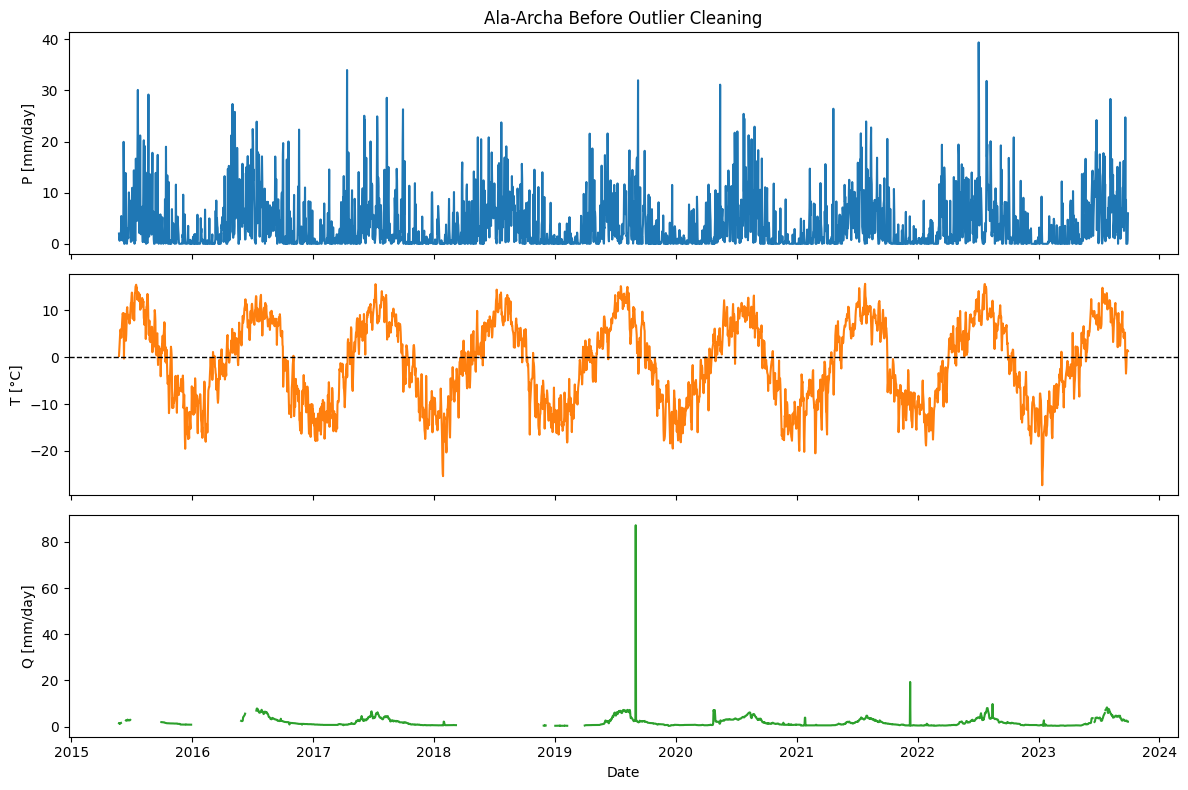

In [16]:
plot_basin_overview(ala_archa_clean_df, "Ala-Archa Before Outlier Cleaning")


The plot already tells us two important things:

- streamflow has gaps, which appear as breaks in the line
- there are also a few suspicious spikes that do not match the surrounding values

Before interpolating anything, we should deal with obvious bad values.


## 4. Inspect and Remove the Most Obvious Ala-Archa Outliers

The plot suggested a very clear outlier around late 2019.

One practical way to find that suspicious value in the table is to look for the **largest streamflow value**. Outlier detection is not always this simple, but here it is a sensible first step.


In [17]:
ala_archa_outlier_idx = ala_archa_clean_df["q_m3s"].idxmax()

ala_archa_clean_df.loc[
    ala_archa_outlier_idx - 3 : ala_archa_outlier_idx + 3,
    ["date", "q_m3s", "q_mm"],
]  # This selects a range of rows around the identified outlier index and shows the date, discharge in m3/s, and discharge in mm/day for those rows. This allows us to inspect the data around the outlier to understand its context and decide how to handle it.


,date,q_m3s,q_mm
1558,2019-08-30,8.343451,2.656719
1559,2019-08-31,8.494733,2.704890
1560,2019-09-01,8.494733,2.704890
1561,2019-09-02,273.735032,87.162625
1562,2019-09-03,7.810644,2.487063
1563,2019-09-04,8.517169,2.712034
1564,2019-09-05,8.142857,2.592846


The jump on `2019-09-02` is far too large relative to the neighboring days.

There is no immediately obvious explanation for the error from the table alone. It is not a simple decimal-place mistake that we can safely correct by hand. In that situation, a reasonable cleaning choice is to mark the value as missing and continue.


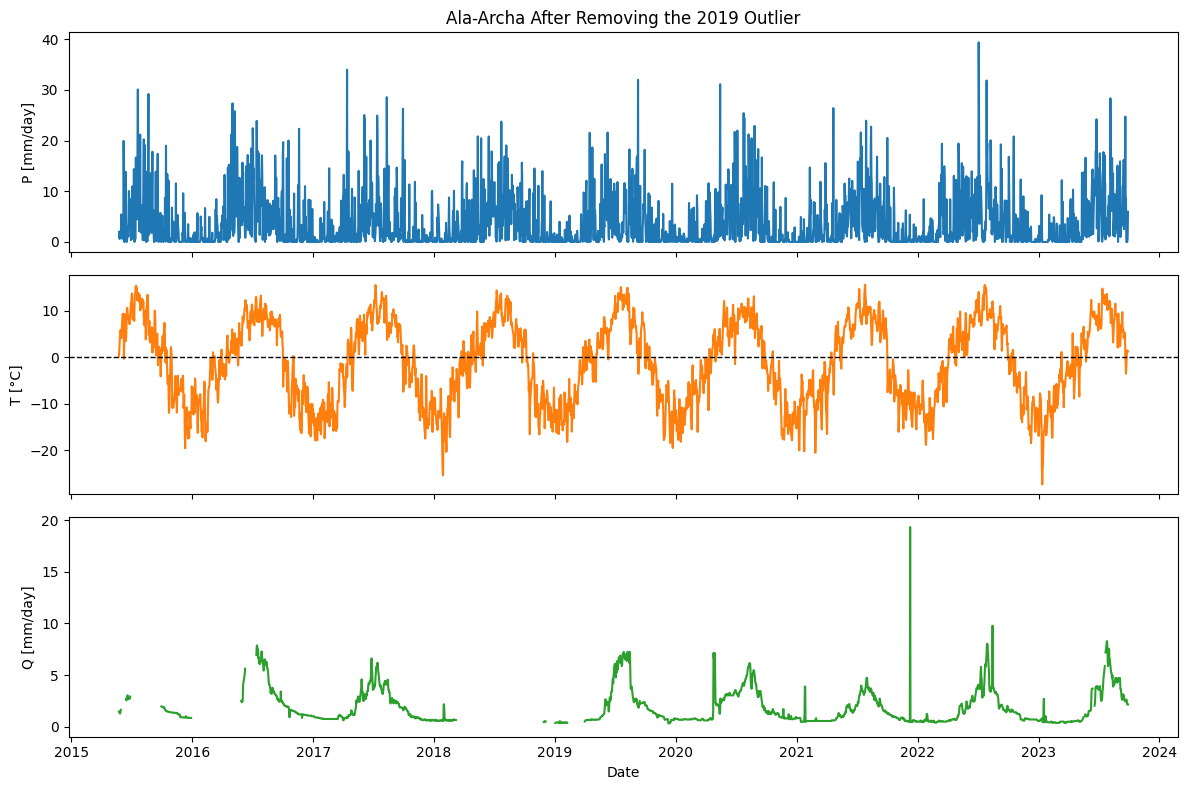

In [18]:
ala_archa_clean_df.loc[ala_archa_outlier_idx, ["q_m3s", "q_mm"]] = (
    np.nan
)  # This sets the identified outlier value in both the m3/s and mm/day columns to `np.nan`, effectively marking it as a missing value that can be handled in the gap-filling process later on.

plot_basin_overview(ala_archa_clean_df, "Ala-Archa After Removing the 2019 Outlier")


Removing the 2019 spike improves the record, but the plot still shows another obvious outlier in 2021.

So we repeat the same process.


In [19]:
ala_archa_outlier_idx = ala_archa_clean_df["q_m3s"].idxmax()

ala_archa_clean_df.loc[
    ala_archa_outlier_idx - 3 : ala_archa_outlier_idx + 3,
    ["date", "q_m3s", "q_mm"],
]


,date,q_m3s,q_mm
2387,2021-12-06,1.711254,0.544897
2388,2021-12-07,1.557191,0.495840
2389,2021-12-08,1.410394,0.449097
2390,2021-12-09,60.735230,19.339293
2391,2021-12-10,1.557191,0.495840
2392,2021-12-11,1.557191,0.495840
2393,2021-12-12,1.557191,0.495840


Again the exact recording mistake is not obvious from the table. The value is simply out of scale with the surrounding winter flow, so marking it as missing is justified here as well.


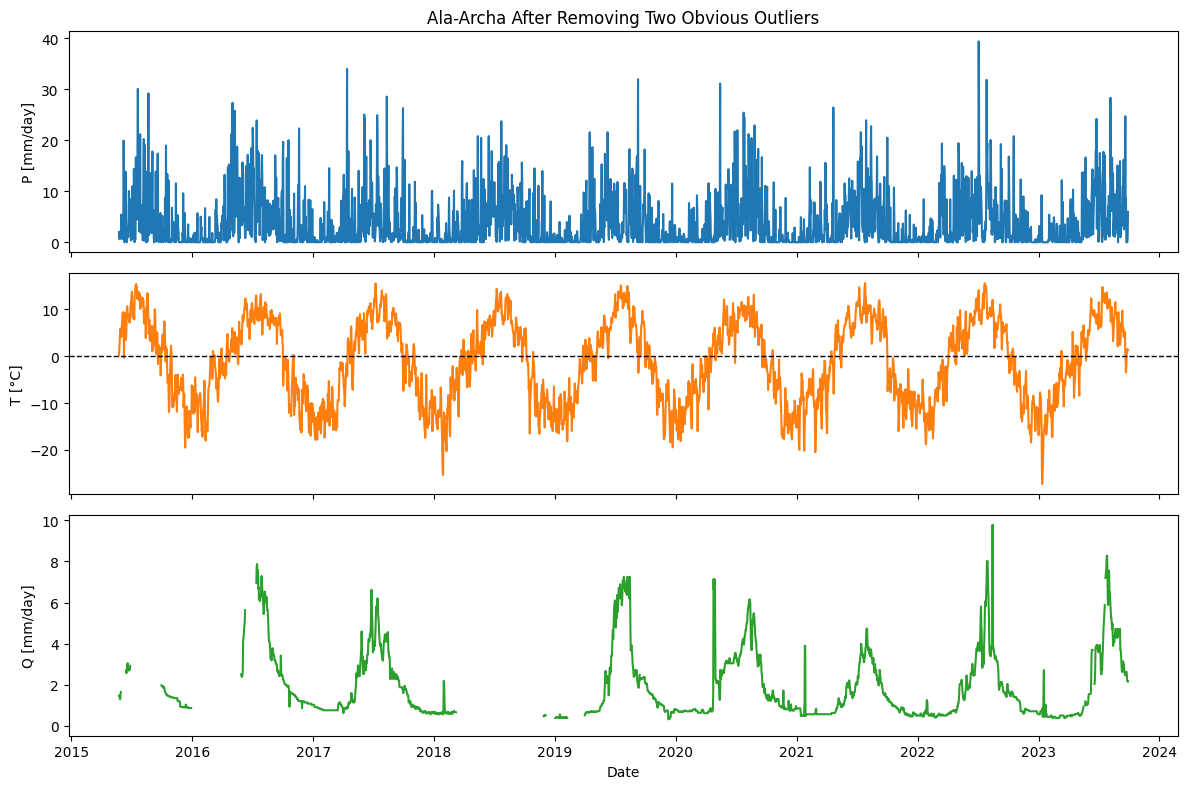

In [20]:
ala_archa_clean_df.loc[ala_archa_outlier_idx, ["q_m3s", "q_mm"]] = np.nan

plot_basin_overview(ala_archa_clean_df, "Ala-Archa After Removing Two Obvious Outliers")


Now the most obvious spike problem is gone.

The main issue that remains is missing data, which shows up in the streamflow series as `NaN` gaps.


So far we have treated the `date` column as something that is simply present in the table. In `pandas`, dates have their own type, and that lets us filter the dataset by specific periods.

That is useful when we want to inspect outliers, zoom in on gaps, or later select calibration windows.


In [21]:
print(ala_archa_clean_df["date"].dtype)

ala_archa_dec_2021_window_df = ala_archa_clean_df[
    ala_archa_clean_df["date"].between("2021-12-06", "2021-12-12")
].copy() # Here we are filtering the cleaned Ala-Archa dataset to a specific date range in December 2021.

print(ala_archa_dec_2021_window_df)


datetime64[us]
           date  precipitation_mm  temperature_degC     q_m3s      q_mm
2387 2021-12-06            0.4002          -10.1076  1.711254  0.544897
2388 2021-12-07            0.9996           -9.6291  1.557191  0.495840
2389 2021-12-08            5.3822           -9.8398  1.410394  0.449097
2390 2021-12-09            0.0400          -11.2675       NaN       NaN
2391 2021-12-10            0.0009           -8.6880  1.557191  0.495840
2392 2021-12-11            0.0013           -7.4578  1.557191  0.495840
2393 2021-12-12            0.2361          -12.4917  1.557191  0.495840


### Exercise 5

The goal of this exercise is to practice filtering a DataFrame by date and to connect that skill to the cleaning work we are doing.

Store these two values:

- `ala_archa_dec_2021_n_rows` as the number of rows in the filtered 2021 window
- `ala_archa_2021_outlier_is_missing` as whether `q_mm` is missing on `2021-12-09`

Try using chatGPT to help you with this problem. 


In [22]:
ala_archa_dec_2021_n_rows = len(ala_archa_dec_2021_window_df)
ala_archa_2021_outlier_is_missing = bool(
    pd.isna(ala_archa_clean_df.loc[ala_archa_clean_df["date"] == "2021-12-09", "q_mm"]).iloc[0]
)

print(ala_archa_dec_2021_n_rows)
print(ala_archa_2021_outlier_is_missing)


7
True


## 5. Measure Gap Lengths and Interpolate Only Short Internal Gaps

A **gap** is just a run of days where the streamflow value is missing, which means the `q_mm` entry is `NaN`.

Now that the obvious outliers are removed, we can focus on those gaps more carefully.

Not all gaps should be treated the same way.

- a one-day or two-day gap inside an otherwise continuous record is often reasonable to interpolate
- a long missing block is different: filling it would require much stronger assumptions

That is why we will only interpolate short internal gaps of up to 3 days and leave longer gaps missing.


In [23]:
def compute_gap_lengths(series: pd.Series) -> pd.Series: # A pd.Series is essentially a single column of data in a DataFrame. Like a single columns in Excel.
    missing_mask = series.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()

    gap_length = pd.Series(0, index=series.index, dtype="int64")
    gap_length.loc[missing_mask] = missing_mask.groupby(group_id).transform("sum").loc[missing_mask].astype("int64")
    return gap_length


ala_archa_clean_df["q_gap_length_days"] = compute_gap_lengths(ala_archa_clean_df["q_mm"])


You do not need to memorize the exact code inside `compute_gap_lengths(...)` right now.

Conceptually, the function does one thing: for every missing day, it counts how long the missing run is.

So:

- observed days get `0`
- a day inside a one-day gap gets `1`
- a day inside a 14-day gap gets `14`


In [24]:
print("A one-day gap example:")
display(
    ala_archa_clean_df.loc[
        ala_archa_clean_df["date"].between("2015-05-25", "2015-05-29"),
        ["date", "q_mm", "q_gap_length_days"],
    ]
)

print("A longer gap example:")
display(
    ala_archa_clean_df.loc[
        ala_archa_clean_df["date"].between("2015-06-01", "2015-06-08"),
        ["date", "q_mm", "q_gap_length_days"],
    ]
)


A one-day gap example:


,date,q_mm,q_gap_length_days
0,2015-05-25,1.460377,0
1,2015-05-26,1.417511,0
2,2015-05-27,NaN,1
3,2015-05-28,1.292744,0
4,2015-05-29,1.333694,0


A longer gap example:


,date,q_mm,q_gap_length_days
7,2015-06-01,NaN,14
8,2015-06-02,NaN,14
9,2015-06-03,NaN,14
10,2015-06-04,NaN,14
11,2015-06-05,NaN,14
12,2015-06-06,NaN,14
13,2015-06-07,NaN,14
14,2015-06-08,NaN,14


That output is the key idea:

- on `2015-05-27`, the streamflow value is missing and belongs to a gap of length `1`
- on `2015-06-01` to `2015-06-08`, each missing day belongs to a much longer gap, so each of those rows gets `14`

The gap length is attached to each missing day because that is exactly what we need when deciding which entries may be interpolated.


Before filling anything, it is worth quantifying how much of the missing record belongs to short gaps and how much belongs to long gaps.


### Exercise 6

The goal of this exercise is to connect the gap-length column to a cleaning decision.

Store these two counts:

- `ala_archa_short_gap_days` for the number of missing streamflow days in gaps of 1 to 3 days
- `ala_archa_long_gap_days` for the number of missing streamflow days in gaps longer than 3 days

Again, try using chatGPT to help with this

In [25]:
ala_archa_short_gap_days = int(ala_archa_clean_df["q_gap_length_days"].between(1, 3).sum())
ala_archa_long_gap_days = int((ala_archa_clean_df["q_gap_length_days"] > 3).sum())

print(ala_archa_short_gap_days)
print(ala_archa_long_gap_days)


12
641


In [26]:
assert ala_archa_short_gap_days == 12, "Ala-Archa should have 12 missing discharge days in gaps of 1 to 3 days."
assert ala_archa_long_gap_days == 641, "Ala-Archa should have 641 missing discharge days in gaps longer than 3 days."


Now we can apply the cleaning rule.

`pandas` has an `.interpolate(...)` method that can estimate missing values from neighboring values. Here we use **linear interpolation**, which means drawing a straight line between the observed values before and after a short gap.

The important part is that we do **not** accept every interpolated value that pandas can compute. We only keep interpolated values where the original gap length was between 1 and 3 days.


In [27]:
ala_archa_interpolated_q_mm = ala_archa_clean_df["q_mm"].interpolate(method="linear", limit_area="inside")
ala_archa_short_gap_mask = ala_archa_clean_df["q_gap_length_days"].between(1, 3)

ala_archa_clean_df["q_mm_clean"] = ala_archa_clean_df["q_mm"]
ala_archa_clean_df.loc[ala_archa_short_gap_mask, "q_mm_clean"] = ala_archa_interpolated_q_mm.loc[ala_archa_short_gap_mask]

ala_archa_clean_df["q_status"] = "observed"
ala_archa_clean_df.loc[ala_archa_short_gap_mask, "q_status"] = "interpolated_1to3d_gap"
ala_archa_clean_df.loc[ala_archa_clean_df["q_mm_clean"].isna(), "q_status"] = "missing_long_gap"

ala_archa_clean_df.head()


,date,precipitation_mm,temperature_degC,q_m3s,q_mm,q_gap_length_days,q_mm_clean,q_status
0,2015-05-25,2.0104,0.2445,4.586328,1.460377,0,1.460377,observed
1,2015-05-26,0.8580,1.4076,4.451707,1.417511,0,1.417511,observed
2,2015-05-27,0.5951,2.9302,NaN,NaN,1,1.355127,interpolated_1to3d_gap
3,2015-05-28,1.4289,4.2443,4.059874,1.292744,0,1.292744,observed
4,2015-05-29,0.8399,5.7689,4.188480,1.333694,0,1.333694,observed


The `q_status` column is useful because it keeps track of where each final discharge value came from:

- `observed` means the original discharge measurement was kept
- `interpolated_1to3d_gap` means a short missing gap was interpolated
- `missing_long_gap` means the value still has no discharge estimate


In [28]:
def plot_cleaned_streamflow(df: pd.DataFrame, title: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 4))

    interpolated_mask = df["q_status"] == "interpolated_1to3d_gap"

    ax.plot(df["date"], df["q_mm_clean"], color="tab:green", linewidth=1.2, label="Cleaned q_mm")
    ax.scatter(
        df.loc[interpolated_mask, "date"],
        df.loc[interpolated_mask, "q_mm_clean"],
        color="tab:red",
        s=25,
        label="Interpolated short gaps",
        zorder=3,
    )

    ax.set_title(title)
    ax.set_ylabel("Q [mm/day]")
    ax.set_xlabel("Date")
    ax.legend()
    plt.show()

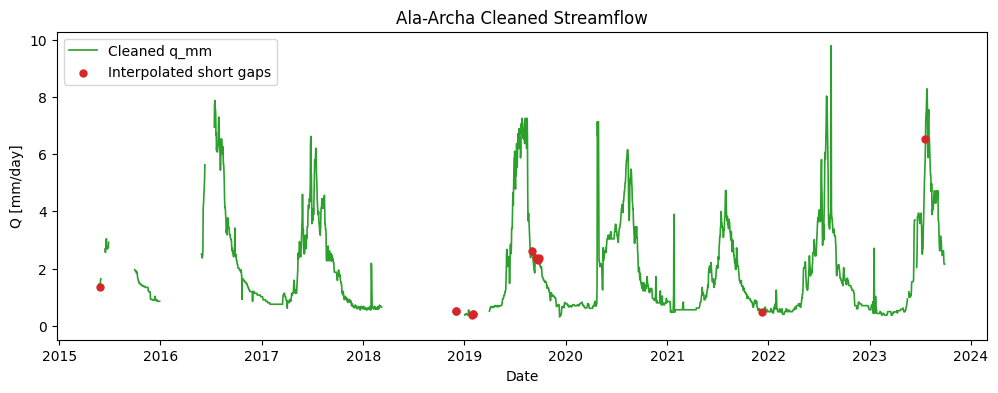

In [29]:
plot_cleaned_streamflow(ala_archa_clean_df, "Ala-Archa Cleaned Streamflow")


The cleaned series only differs from the observed series where a short internal gap was interpolated.

Long gaps still remain missing, which is what we want. We do not have a reliable way to fill those longer missing periods inside a cleaning notebook, and forcing a value there would introduce stronger assumptions that could later hurt model calibration.


### Exercise 7

The goal of this exercise is to check whether the cleaning rule behaved the way we intended.

Store these four values:

- `ala_archa_interpolated_days` as the number of rows with `q_status == "interpolated_1to3d_gap"`
- `ala_archa_remaining_missing_days` as the number of rows with `q_status == "missing_long_gap"`
- `ala_archa_first_interpolated_q_mm` as the cleaned value on `2015-05-27`
- `ala_archa_long_gap_is_still_missing` as whether `q_mm_clean` is missing on `2015-06-01`


In [30]:
ala_archa_interpolated_days = int((ala_archa_clean_df["q_status"] == "interpolated_1to3d_gap").sum())
ala_archa_remaining_missing_days = int((ala_archa_clean_df["q_status"] == "missing_long_gap").sum())
ala_archa_first_interpolated_q_mm = float(
    ala_archa_clean_df.loc[ala_archa_clean_df["date"] == "2015-05-27", "q_mm_clean"].iloc[0]
)
ala_archa_long_gap_is_still_missing = bool(
    pd.isna(ala_archa_clean_df.loc[ala_archa_clean_df["date"] == "2015-06-01", "q_mm_clean"]).iloc[0]
)

print(ala_archa_interpolated_days)
print(ala_archa_remaining_missing_days)
print(ala_archa_first_interpolated_q_mm)
print(ala_archa_long_gap_is_still_missing)


12
641
1.3551274787221765
True


In [31]:
assert ala_archa_interpolated_days == 12, "Ala-Archa should have 12 interpolated short-gap days."
assert ala_archa_remaining_missing_days == 641, "Ala-Archa should still have 641 long-gap missing days."
assert np.isclose(ala_archa_first_interpolated_q_mm, 1.3551274787221765), (
    "The cleaned Ala-Archa value on 2015-05-27 is not correct. Recheck the short-gap interpolation step."
)
assert ala_archa_long_gap_is_still_missing is True, (
    "The long gap starting on 2015-06-01 should still be missing after cleaning."
)


## 6. Save the Cleaned Ala-Archa Dataset

At this point the daily dataset is coherent:

- precipitation and temperature are in the same DataFrame
- discharge is aligned to the same dates
- the two obvious outliers were removed
- short gaps were interpolated
- long gaps were left missing

Now we want to save that cleaned dataset so we can reuse it later when we prepare calibration data for the hydrological model.


In [ ]:
ala_archa_output_folder = DATA_ROOT / ala_archa_folder / "03_processed"
ala_archa_output_folder.mkdir(parents=True, exist_ok=True)

ala_archa_output_path = ala_archa_output_folder / "cleaned_daily_dataset.csv"
ala_archa_clean_df.to_csv(ala_archa_output_path, index=False)

print(ala_archa_output_path)
print(ala_archa_clean_df.head())


## 7. Final Exercise: Repeat the Workflow for Alamedin

Now repeat the same workflow for **Alamedin**.

The objective is the same as before: build one coherent daily dataset, clean the obvious discharge problems, interpolate only short internal gaps, and save the result.

Work through these steps carefully:

1. read precipitation, temperature, and streamflow
2. merge the forcing variables into one DataFrame
3. convert `q_m3s` to `q_mm`
4. remove the two obvious one-day outliers on `2019-06-12` and `2019-07-13`
5. compute `q_gap_length_days`
6. interpolate only gaps of up to 3 days
7. create `q_mm_clean` and `q_status`
8. save the cleaned daily dataset


In [ ]:
alamedin_precipitation_path = DATA_ROOT / alamedin_folder / "02_forcing" / "era5_precipitation_daily.csv"
alamedin_streamflow_path = (
    DATA_ROOT / alamedin_folder / "01_gauge_data" / f"q{alamedin_gauge_code}_not_to_be_shared.csv"
)

alamedin_precipitation_df = pd.read_csv(alamedin_precipitation_path, parse_dates=["date"])
alamedin_temperature_df = pd.read_csv(alamedin_temperature_path, parse_dates=["date"])
alamedin_forcing_df = alamedin_precipitation_df.merge(
    alamedin_temperature_df,
    on="date",
    how="inner",
).sort_values("date").reset_index(drop=True)

alamedin_streamflow_df = pd.read_csv(alamedin_streamflow_path)
alamedin_streamflow_df["date"] = pd.to_datetime(alamedin_streamflow_df["local_date_time"]).dt.normalize()
alamedin_streamflow_df = alamedin_streamflow_df[["date", "q_m3s"]].copy()

alamedin_start_date = alamedin_streamflow_df["date"].min()
alamedin_end_date = alamedin_streamflow_df["date"].max()

alamedin_clean_df = (
    alamedin_forcing_df[alamedin_forcing_df["date"].between(alamedin_start_date, alamedin_end_date)]
    .merge(alamedin_streamflow_df, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)
alamedin_clean_df["q_mm"] = alamedin_clean_df["q_m3s"] * 86.4 / alamedin_area_km2
alamedin_clean_df = alamedin_clean_df[["date", "precipitation_mm", "temperature_degC", "q_m3s", "q_mm"]].copy()

alamedin_outlier_dates = pd.to_datetime(["2019-06-12", "2019-07-13"])
alamedin_clean_df.loc[alamedin_clean_df["date"].isin(alamedin_outlier_dates), ["q_m3s", "q_mm"]] = np.nan

alamedin_clean_df["q_gap_length_days"] = compute_gap_lengths(alamedin_clean_df["q_mm"])

alamedin_interpolated_q_mm = alamedin_clean_df["q_mm"].interpolate(method="linear", limit_area="inside")
alamedin_short_gap_mask = alamedin_clean_df["q_gap_length_days"].between(1, 3)

alamedin_clean_df["q_mm_clean"] = alamedin_clean_df["q_mm"]
alamedin_clean_df.loc[alamedin_short_gap_mask, "q_mm_clean"] = alamedin_interpolated_q_mm.loc[alamedin_short_gap_mask]

alamedin_clean_df["q_status"] = "observed"
alamedin_clean_df.loc[alamedin_short_gap_mask, "q_status"] = "interpolated_1to3d_gap"
alamedin_clean_df.loc[alamedin_clean_df["q_mm_clean"].isna(), "q_status"] = "missing_long_gap"

alamedin_output_folder = DATA_ROOT / alamedin_folder / "03_processed"
alamedin_output_folder.mkdir(parents=True, exist_ok=True)

alamedin_output_path = alamedin_output_folder / "cleaned_daily_dataset.csv"
alamedin_clean_df.to_csv(alamedin_output_path, index=False)

print(alamedin_clean_df.head())
print()
print(alamedin_clean_df["q_status"].value_counts())
print()
print(alamedin_output_path)


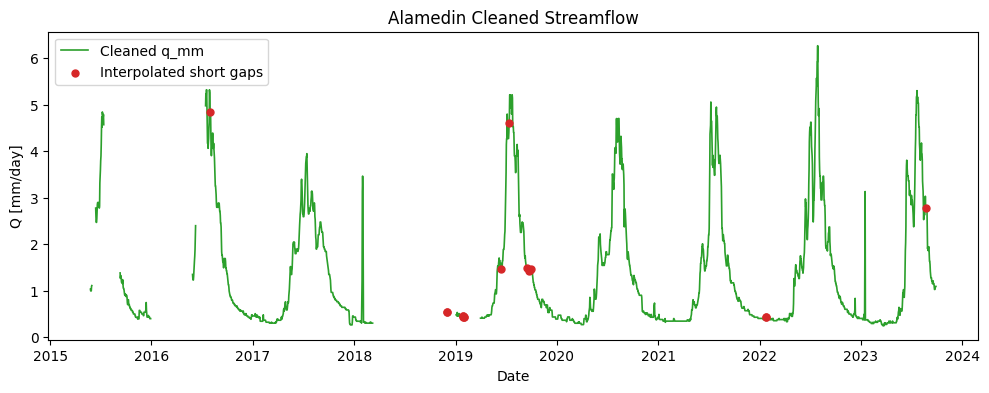

In [34]:
plot_cleaned_streamflow(alamedin_clean_df, "Alamedin Cleaned Streamflow")


In [35]:
alamedin_interpolated_days = int((alamedin_clean_df["q_status"] == "interpolated_1to3d_gap").sum())
alamedin_remaining_missing_days = int((alamedin_clean_df["q_status"] == "missing_long_gap").sum())
alamedin_long_gap_is_still_missing = bool(
    pd.isna(alamedin_clean_df.loc[alamedin_clean_df["date"] == "2015-06-01", "q_mm_clean"]).iloc[0]
)

print(alamedin_interpolated_days)
print(alamedin_remaining_missing_days)
print(alamedin_long_gap_is_still_missing)


17
602
True


In [36]:
assert len(alamedin_clean_df) == 3048, "Alamedin should have 3048 daily rows over the streamflow period."
assert int(alamedin_clean_df["q_mm"].isna().sum()) == 619, (
    "Alamedin should have 619 missing `q_mm` values after removing the two obvious outliers."
)
assert alamedin_interpolated_days == 17, "Alamedin should have 17 interpolated short-gap days."
assert alamedin_remaining_missing_days == 602, "Alamedin should still have 602 long-gap missing days."
assert alamedin_long_gap_is_still_missing is True, "The long Alamedin gap starting on 2015-06-01 should still be missing."


## Wrap-Up

In this notebook you cleaned real basin datasets into a form that is useful for later modelling work.

You practiced how to:

- represent missing values with `np.nan`
- read CSV files into `pandas` DataFrames
- merge multiple tables into one daily dataset
- work with `pandas` dates
- convert discharge into `mm/day`
- use plots to identify suspicious values
- remove obvious outliers by marking them missing
- measure gap lengths
- interpolate only short internal gaps
- save cleaned datasets for later reuse

The important principle is that cleaning is not the same thing as inventing hydrology. We used interpolation only where the missing periods were short enough that the assumption stayed mild. Longer gaps were left missing so that later modelling work is not built on stronger, hidden assumptions.
